# Cyclistic Bike-Share Case Study: Executive Walkthrough

**Business Question:** How do annual members and casual riders use Cyclistic bikes differently, and what strategies can convert casual riders into annual members?

This notebook provides an interactive walkthrough of the aggregated results across **5.47 million cleaned trips** (July 2024 – June 2025). The production-grade streaming pipeline that downloads, validates, and aggregates the multi-gigabyte raw trip data in chunks lives in `scripts/run_analysis.py`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root robustly whether executed from root or notebooks/
current = Path.cwd()
root = current if (current / 'data').exists() else current.parent
processed_dir = root / 'data' / 'processed'

monthly = pd.read_csv(processed_dir / 'monthly_member_summary.csv')
daily = pd.read_csv(processed_dir / 'day_member_summary.csv')
hour = pd.read_csv(processed_dir / 'hour_member_summary.csv')
bike = pd.read_csv(processed_dir / 'rideable_member_summary.csv')
quality = pd.read_csv(processed_dir / 'data_quality_report.csv')

print(f"Loaded summaries from {processed_dir.relative_to(root)}/")
print(f"Total cleaned trips analyzed: {monthly['rides'].sum():,}")

Loaded summaries from data/processed/
Total cleaned trips analyzed: 5,465,569


## 1. Data Quality & Exclusion Governance

Data quality rules filter out rides shorter than 1 minute (false docks/accidental unlocks), rides exceeding 24 hours (lost/stolen bikes), unparseable timestamps, and unconfirmed rider categories.

In [2]:
# Monthly Data Quality Audit Table
quality

source_month,input_rows,invalid_timestamp_rows,invalid_rider_type_rows,duration_outside_rule_rows,kept_rows
2024-07,748962,0,0,17582,731380
2024-08,755639,0,0,17989,737650
2024-09,821276,0,0,21083,800193
2024-10,616281,0,0,11392,604889
2024-11,335075,0,0,5688,329387
2024-12,178372,0,0,3487,174885
2025-01,138689,0,0,2915,135774
2025-02,151880,0,0,2792,149088
2025-03,298155,0,0,6817,291338
2025-04,371341,0,0,8186,363155


## 2. High-Level Summary by Rider Type

- **Members** generate nearly two-thirds (**63.7%**) of total trip volume.
- **Casual riders** take substantially longer trips (**20.6 minutes** average vs **12.0 minutes** for members).

In [3]:
totals = monthly.groupby('rider_type', as_index=False).agg(rides=('rides', 'sum'), total_minutes=('total_minutes', 'sum'))
totals['average_ride_minutes'] = (totals['total_minutes'] / totals['rides']).round(1)
totals['share_pct'] = (totals['rides'] / totals['rides'].sum() * 100).round(1)
totals

rider_type,rides,total_minutes,average_ride_minutes,share_pct
casual,1982411,4.089425e+07,20.6,36.3
member,3483158,4.185529e+07,12.0,63.7


## 3. Diurnal Analysis: Commuter Rush vs. Leisure Curve

Plotting trip volume across 24 hours provides the clearest visual distinction between **annual members** and **casual riders**:

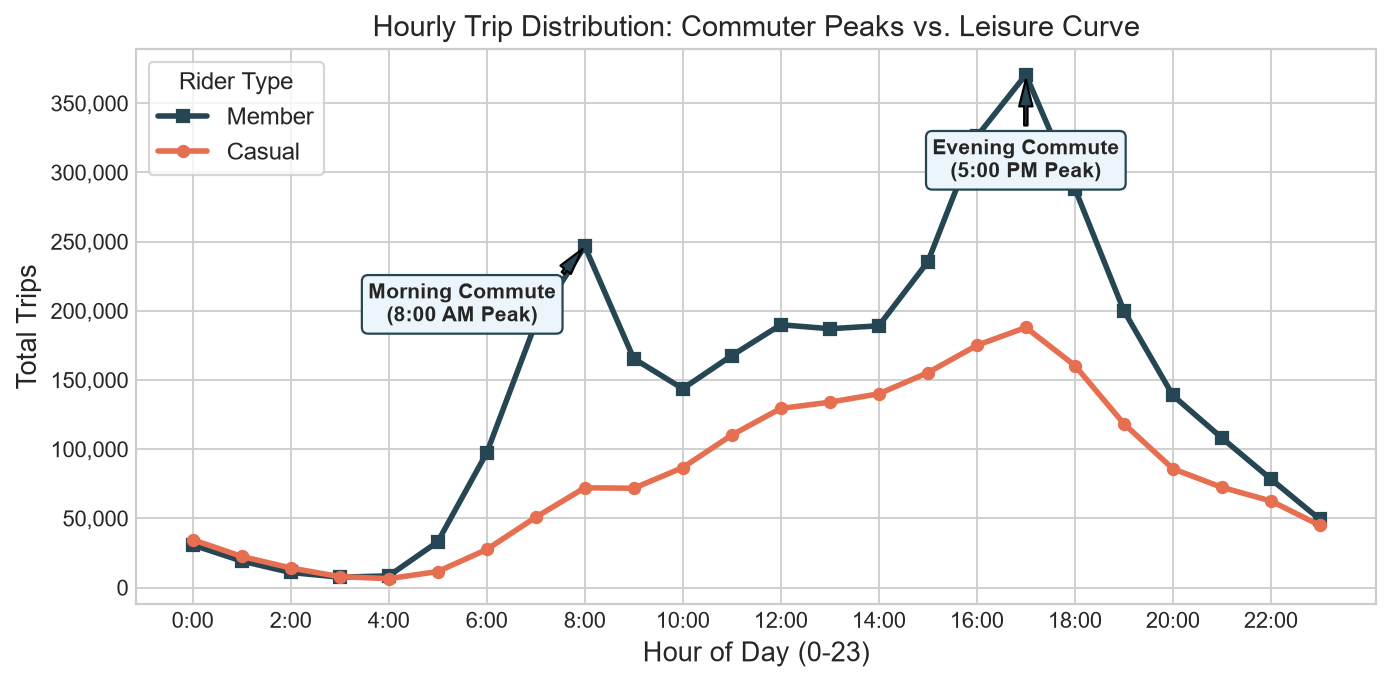

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = {'casual': '#E76F51', 'member': '#264653'}
for rider in ('member', 'casual'):
    view = hour[hour.rider_type.eq(rider)].sort_values('hour')
    ax.plot(view.hour, view.rides, marker='s' if rider == 'member' else 'o', linewidth=2.5, color=colors[rider], label=rider.title())
ax.set(title="Hourly Trip Distribution: Commuter Peaks vs. Leisure Curve", xlabel="Hour of Day (0-23)", ylabel="Total Trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Rider Type")
plt.show()

## 4. Trip Duration by Day of Week

Members ride with predictable consistency Monday through Sunday (~12 minutes). In contrast, casual riders exhibit leisure behavior that spikes significantly on weekends (~24 minutes).

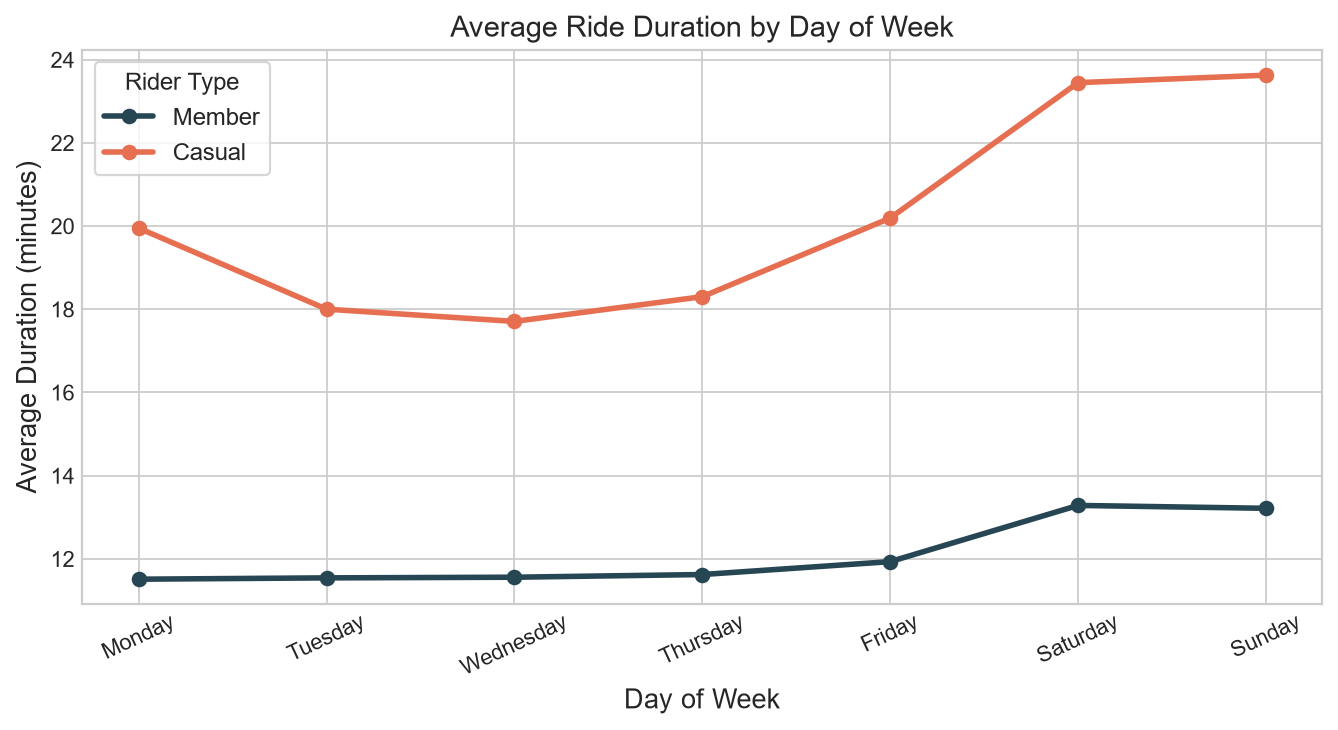

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for rider in ('member', 'casual'):
    view = daily[daily.rider_type.eq(rider)].set_index('weekday').reindex(day_order).reset_index()
    ax.plot(view.weekday, view.average_ride_minutes, marker='o', linewidth=2.5, color=colors[rider], label=rider.title())
ax.set(title="Average Ride Duration by Day of Week", xlabel="Day of Week", ylabel="Average Duration (minutes)")
ax.legend(title="Rider Type")
plt.show()

## 5. Monthly Seasonality Trends

Summer volume peaks heavily for casual riders, but winter volume drops by >85%. In contrast, members maintain an active commuting baseline year-round.

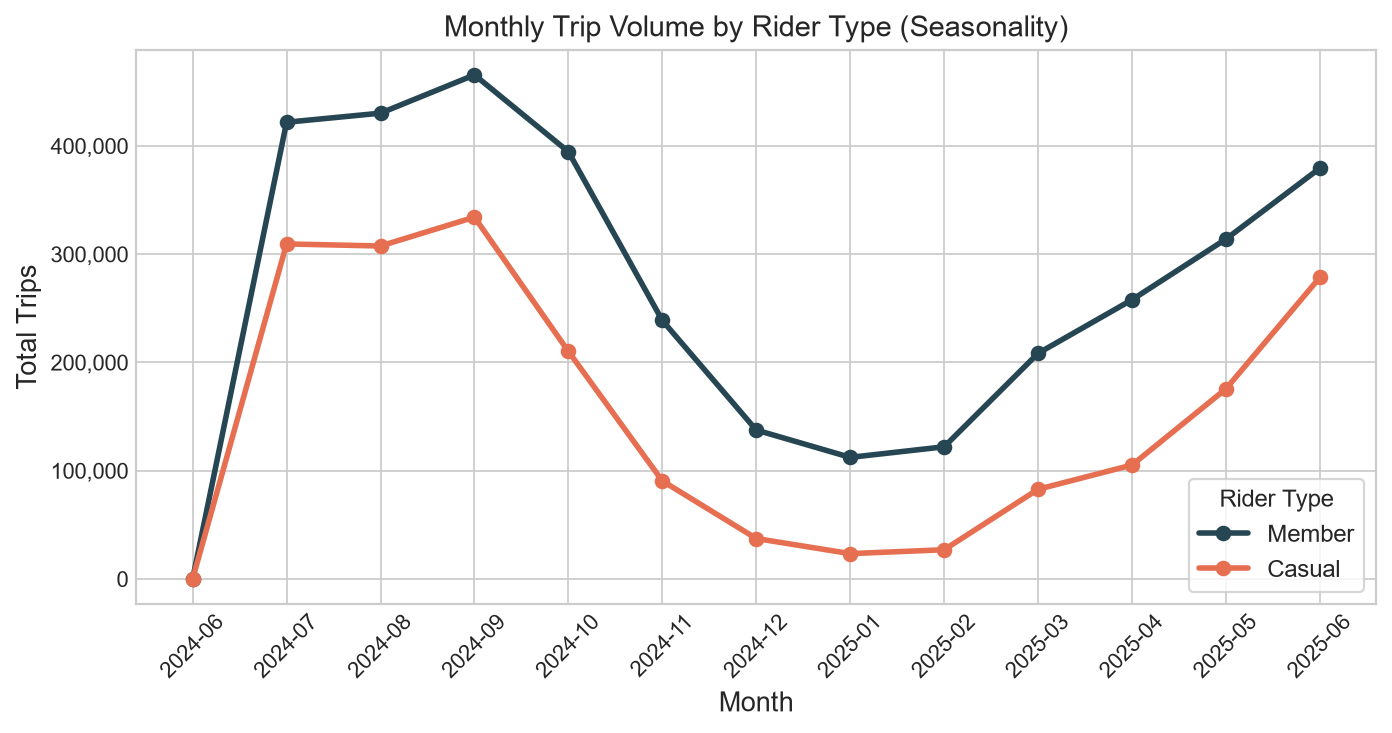

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for rider in ('member', 'casual'):
    view = monthly[monthly.rider_type.eq(rider)]
    ax.plot(view.month, view.rides, marker='o', linewidth=2.5, color=colors[rider], label=rider.title())
ax.set(title="Monthly Trip Volume by Rider Type (Seasonality)", xlabel="Month", ylabel="Total Trips")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Rider Type")
plt.show()

## 6. Strategic Recommendations for Cyclistic Marketing

1. **Launch Weekday Commute Trials:** Target the 63% of casual riders using bikes on weekdays with a 14-day free member-speed pass in September to build routine commute habits.
2. **Dynamic In-App Cost Comparison:** After rides >20 minutes, show casual users how much they would save with an annual membership.
3. **End-of-Summer Pass Credit:** Allow summer casual riders to apply 100% of their summer ride spend toward an annual pass.